# 🌿 Khassab Project - Smart Waste Estimation with ML

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Upload CSV
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving kassab_ml_dataset.csv to kassab_ml_dataset.csv


,Region,Trees_Planted,Flowers_Planted,Year,Num_Parks,Parks_Area,Green_Area,Visitors_000,Overnight_Stay_000,Spending_SAR_Mn,Average Length of Stay (Night),Avergae Spending per Trip (SAR),Average Spending per Night (SAR),Type,Estimated_Waste_kg
0,Aseer Province,830298.0,1158144.0,2022,NaN,NaN,NaN,5971.0,39079.0,7068.0,6.5,"1,184",181.0,Domestic,280008850.8
1,Aseer Province,830298.0,1158144.0,2022,NaN,NaN,NaN,2308.0,15059.0,3414.0,6.5,"1,479",227.0,Domestic,41707406.4
2,Aseer Province,830298.0,1158144.0,2022,NaN,NaN,NaN,1179.0,8142.0,1329.0,6.9,"1,127",163.0,Domestic,11519301.6
3,Aseer Province,830298.0,1158144.0,2022,NaN,NaN,NaN,2484.0,15878.0,2325.0,6.4,936,146.0,Domestic,47329142.4
4,Aseer Province,830298.0,1158144.0,2022,NaN,NaN,NaN,74.0,1666.0,361.0,22.5,"4,869",216.0,Inbound,147940.8


In [ ]:
def clean_num(val):
    try:
        return float(str(val).replace(",", "").strip())
    except:
        return np.nan

cols = ["Visitors_000", "Overnight_Stay_000", "Spending_SAR_Mn",
        "Trees_Planted", "Flowers_Planted", "Num_Parks", "Parks_Area", "Green_Area"]

for col in cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_num)

# Target: estimated organic waste
df["Estimated_Waste_kg"] = df["Visitors_000"] * df["Overnight_Stay_000"] * 1.2


## 📊 Exploratory Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Region                            16 non-null     object 
 1   Trees_Planted                     8 non-null      float64
 2   Flowers_Planted                   8 non-null      float64
 3   Year                              16 non-null     int64  
 4   Num_Parks                         8 non-null      float64
 5   Parks_Area                        8 non-null      float64
 6   Green_Area                        8 non-null      float64
 7   Visitors_000                      16 non-null     float64
 8   Overnight_Stay_000                16 non-null     float64
 9   Spending_SAR_Mn                   16 non-null     float64
 10  Average Length of Stay (Night)    16 non-null     float64
 11  Avergae Spending per Trip (SAR)   16 non-null     object 
 12  Average Sp

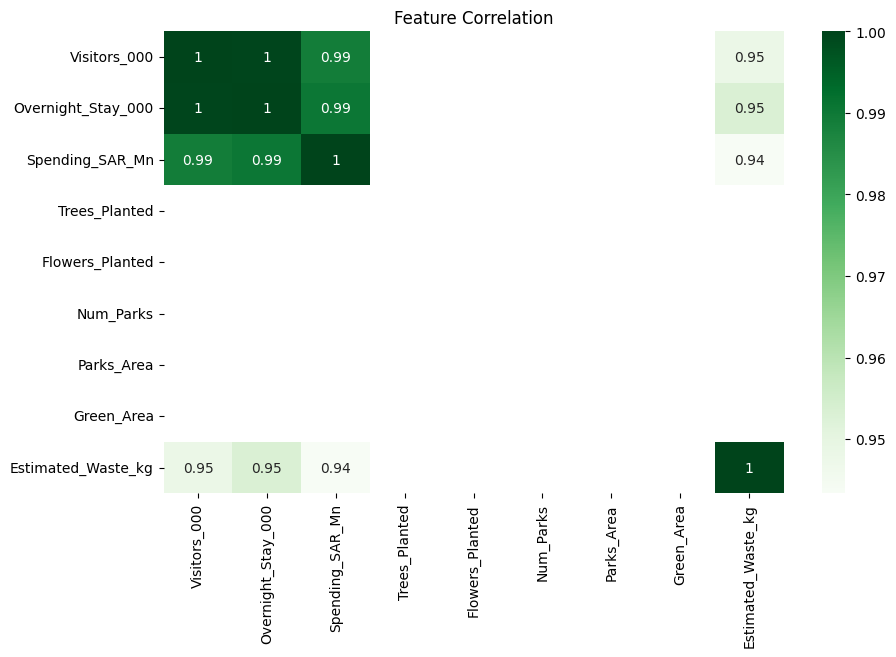

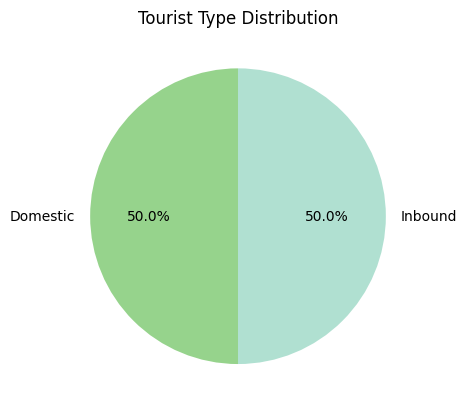

In [ ]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[cols + ["Estimated_Waste_kg"]].corr(), annot=True, cmap='Greens')
plt.title("Feature Correlation")
plt.show()

# Pie: Tourist Type
if "Type" in df.columns:
    df["Type"].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#96d38c', '#b0e0d1'])
    plt.title("Tourist Type Distribution")
    plt.ylabel("")
    plt.show()


## 🧠 ML Model - Estimate Organic Waste

In [ ]:
minimal_features = ["Visitors_000", "Overnight_Stay_000", "Spending_SAR_Mn"]
df_model = df.dropna(subset=minimal_features + ["Estimated_Waste_kg"])
X = df_model[minimal_features]
y = df_model["Estimated_Waste_kg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("🔍 Test R²:", r2_score(y_test, y_pred))
print("📉 Test MSE:", mean_squared_error(y_test, y_pred))


🔍 Test R²: 0.9252251591197412
📉 Test MSE: 1014339414843965.6


In [ ]:
# Enhanced model if features available
env_features = ["Trees_Planted", "Flowers_Planted", "Num_Parks", "Parks_Area", "Green_Area"]
used_env = [f for f in env_features if f in df.columns]
if used_env:
    X_env = df_model[minimal_features + used_env]
    X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_env, y, test_size=0.25, random_state=42)

    model_e = RandomForestRegressor(n_estimators=100, random_state=42)
    model_e.fit(X_train_e, y_train_e)

    y_pred_e = model_e.predict(X_test_e)
    print("\n🌱 Enhanced Model:")
    print("🔍 Test R²:", r2_score(y_test_e, y_pred_e))
    print("📉 Test MSE:", mean_squared_error(y_test_e, y_pred_e))

else:
    print("⚠️ No environmental features available.")



🌱 Enhanced Model:
🔍 Test R²: 0.9257520975520646
📉 Test MSE: 1007191363242525.0
